In [1]:
%matplotlib widget

In [2]:
# import sat module
from satellite_plotter2 import SatellitePlotter
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timezone

In [ ]:
# Create a plotter without frequency filtering at current time
plotter = SatellitePlotter()  # No frequency limits
plotter.initialize()

In [ ]:
# All satellites
all_positions = plotter.compute_positions(frequency_filter=False)
plotter.plot_equatorial()


In [ ]:
# Pick a box ra_min, ra_max, dec_min, dec_max in deg
plotter.plot_region_box(140, 160, -10, 10, positions=all_positions)

In [ ]:
# Filter in frequency in MHz
plotter = SatellitePlotter(min_freq=300, max_freq=2000)
plotter.initialize()
filtered_positions = plotter.compute_positions(frequency_filter=True)
plotter.plot_region_box(140, 160, -10, 10, positions=filtered_positions)

In [ ]:
# Future position
unix_timestamp = 1711209600  # Example: March 23, 2024 00:00:00 UTC (seconds accuracy)
# Convert to datetime in UTC
dt_utc = datetime.fromtimestamp(unix_timestamp, tz=timezone.utc)

# Print the UTC datetime
print(dt_utc)  # Output: 2024-03-23 00:00:00+00:00

dt_utc = datetime.strptime("2025-03-24 21:30:45", "%Y-%m-%d %H:%M:%S")
print(dt_utc) 

future_positions = plotter.compute_positions(time=dt_utc, frequency_filter=True)
plotter.plot_region_box(140, 160, -10, 10, positions=future_positions)

In [3]:
geo_sats = SatellitePlotter(min_freq=300, max_freq=2000)

In [4]:
geo_sats.initialize(url="https://celestrak.org/NORAD/elements/gp.php?GROUP=geo&FORMAT=tle")

2025-03-23 23:35:36,946 - INFO - Fetching SatNOGS catalog...
2025-03-23 23:35:39,210 - INFO - Fetching TLE data from Celestrak...
2025-03-23 23:35:41,239 - INFO - Retrieved 565 TLEs
2025-03-23 23:35:41,291 - INFO - Found 878 satellites in frequency range 300-2000 MHz
2025-03-23 23:35:41,293 - INFO - Computing positions for satellites at 2025-03-23 21:35:41.287759+00:00
2025-03-23 23:35:41,305 - INFO - Computed positions for 8 frequency-filtered satellites at 2025-03-23 21:35:41.287759+00:00


2025-03-23 23:35:43,388 - INFO - Found 878 satellites in frequency range 300-2000 MHz
2025-03-23 23:35:43,389 - INFO - Computing positions for satellites at 2025-03-23 21:35:43.381794+00:00
2025-03-23 23:35:43,402 - INFO - Computed positions for 8 frequency-filtered satellites at 2025-03-23 21:35:43.381794+00:00
2025-03-23 23:35:43,404 - INFO - Plotting 8 satellites on equatorial projection


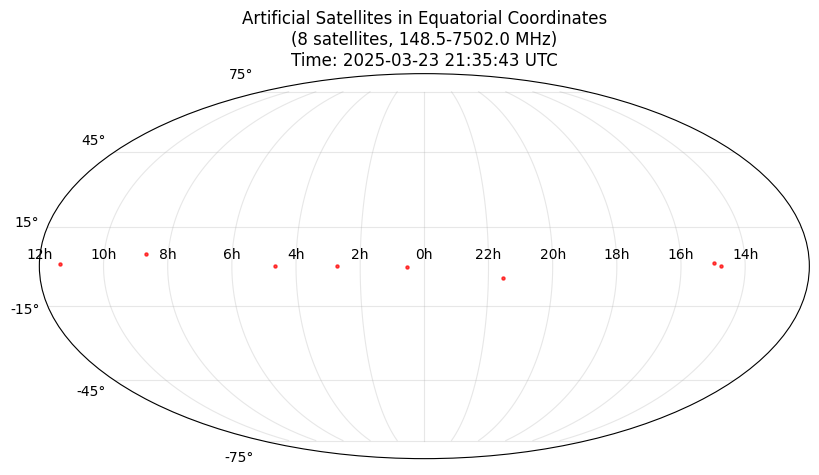

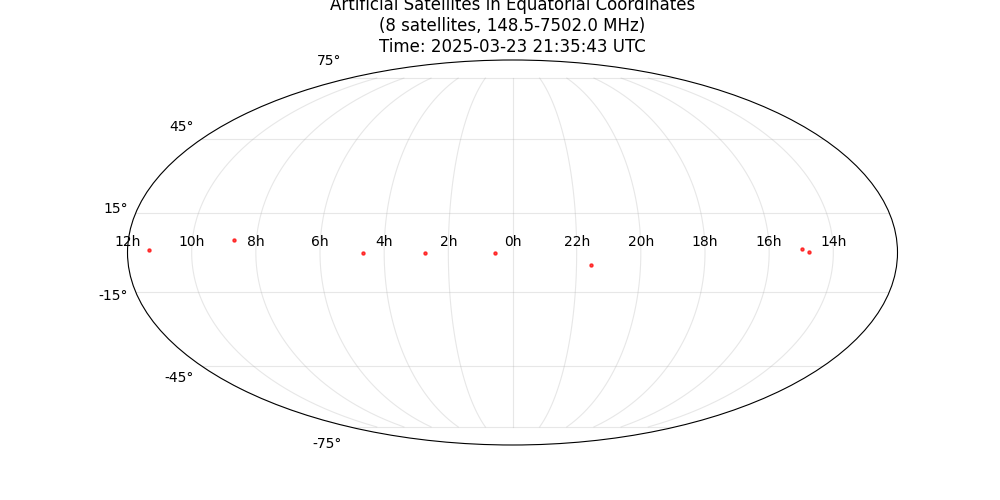

In [5]:
# Geo satellites
geo_positions = geo_sats.compute_positions(frequency_filter=True)
geo_sats.plot_equatorial()

2025-03-23 23:48:46,735 - INFO - Plotting 8 satellites in region box
2025-03-23 23:48:46,776 - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


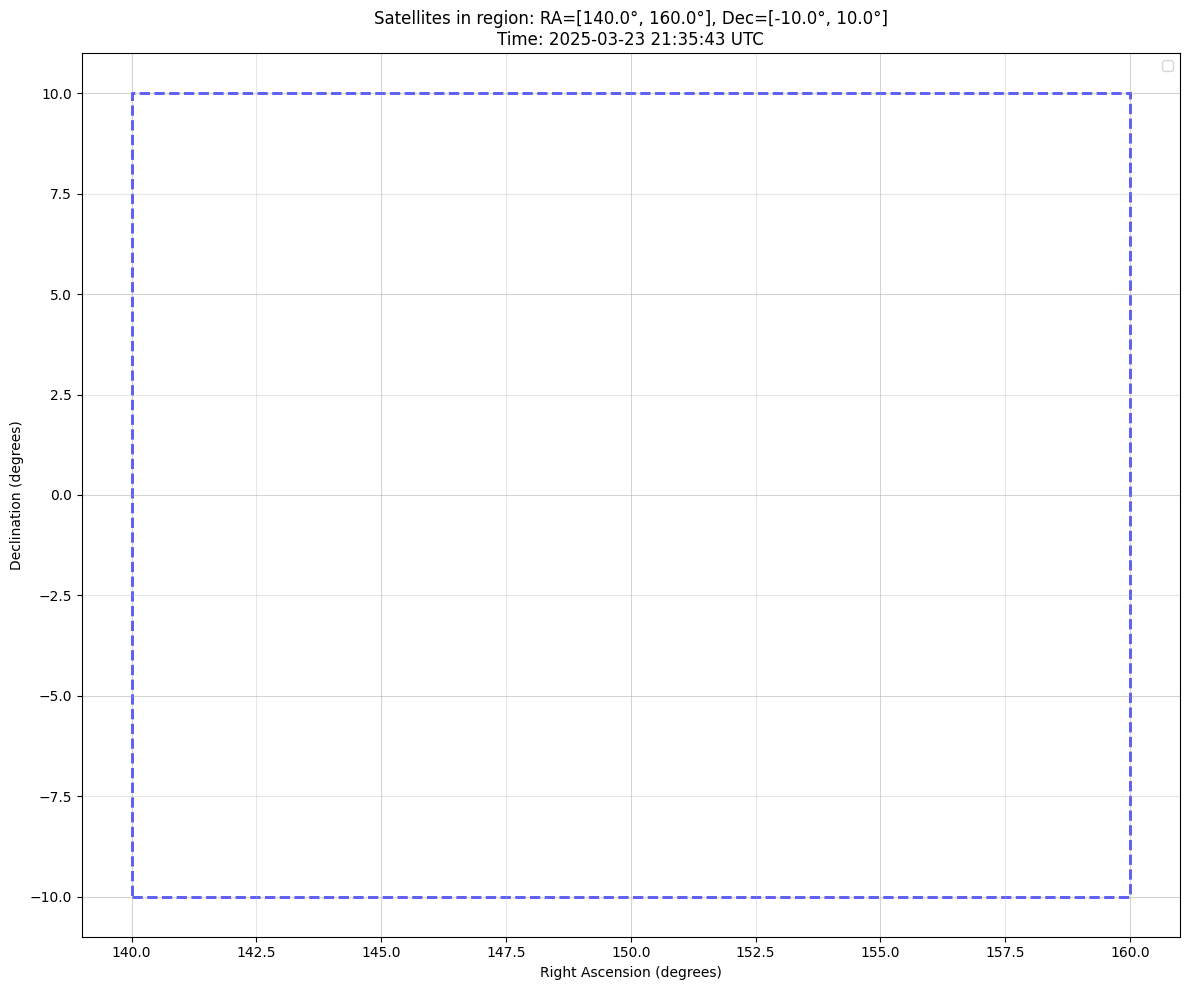

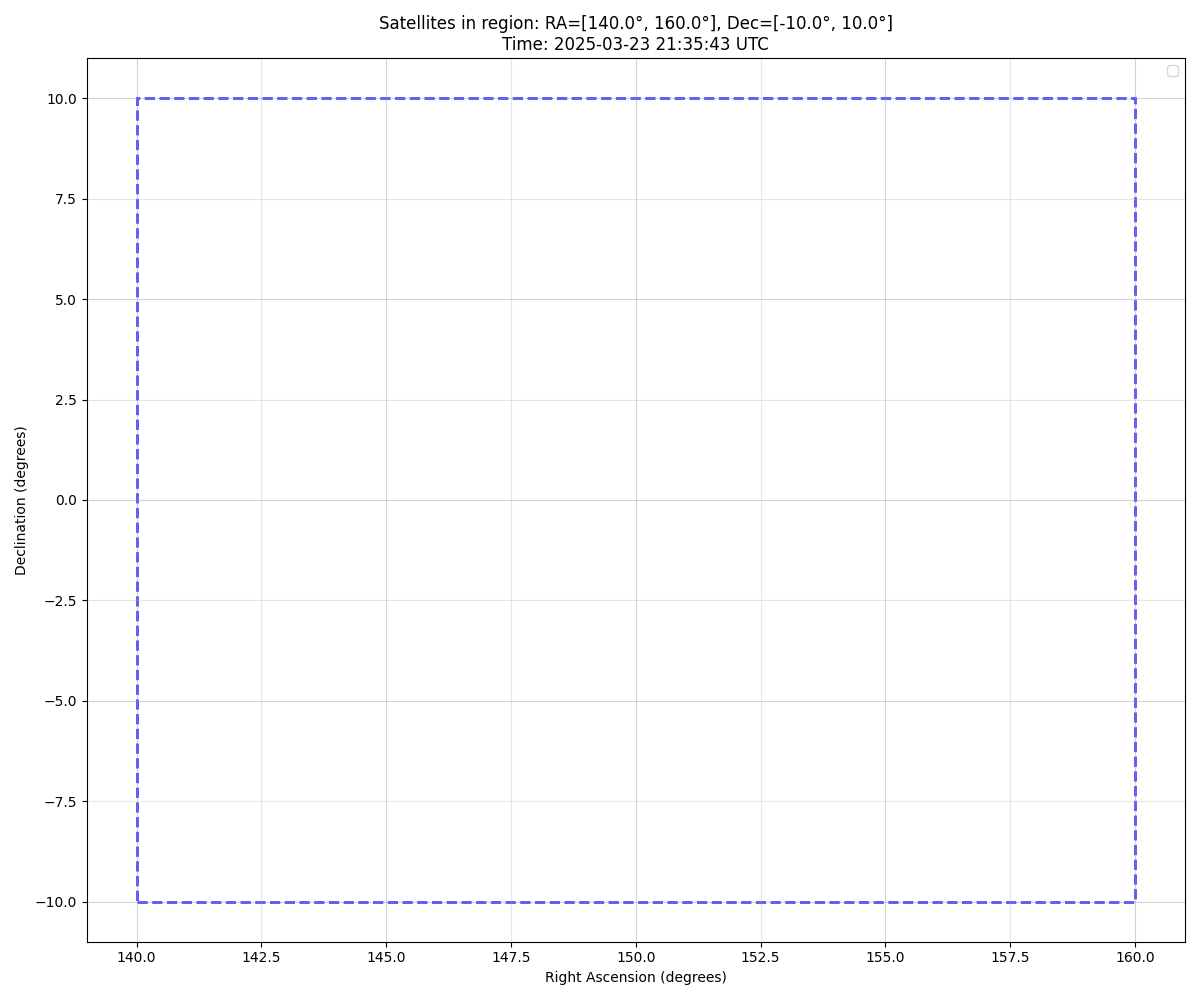

In [15]:
geo_sats.plot_region_box(140, 160, -10, 10, positions=geo_positions)

In [7]:
frequencies = [sat.get('frequency') for sat in geo_positions if sat.get('frequency') is not None]
if frequencies:
    print(f"Min frequency: {min(frequencies)}")
    print(f"Max frequency: {max(frequencies)}")
print(f"Initialized frequency range: {geo_sats.min_freq} - {geo_sats.max_freq}")

Min frequency: 148.545
Max frequency: 7502.0
Initialized frequency range: 300 - 2000


In [14]:
print(frequencies)

[1545.9525, 1552.65, 7502.0, 1694.1, 148.545, 1690.5, 1691.0, 1686.6]
